Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import plotly.express as px

Accessing Csv file

In [2]:
df = pd.read_csv("student_performance.csv")
df.head(3)

,Name,Age,Gender,Major,Living_Area,Parent_Education,Scholarship_Status,Part_Time_Job,Extracurricular_Activities,Internet_Access,...,Sleep_Hours_Per_Day,Attendance_Rate,Stress_Level,Exam_Proximity,Math_Score,Science_Score,Language_Score,History_Score,Average_Score,Grade
0,Linda Johnson,24,Female,Arts,Rural,Bachelor,No,No,No,Yes,...,6.69,77.3,3.6,No,52,43,69,66,58,C
1,Thomas Thomas,21,Male,Arts,Suburban,Master,No,No,No,Yes,...,7.34,59.7,7.3,Yes,59,64,74,68,66,C
2,Joseph Rodriguez,23,Male,STEM,Suburban,High School,Yes,No,No,Yes,...,6.78,56.0,2.9,No,81,72,67,69,72,B


Partition by Living area

<Axes: ylabel='Living_Area'>

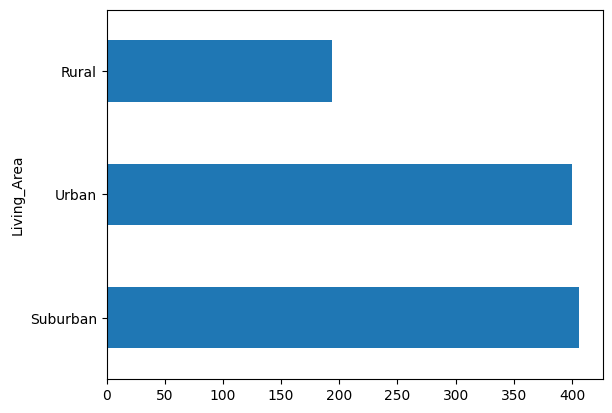

In [3]:
df['Living_Area'].value_counts().plot(kind="barh")

Checking Data

In [ ]:
df.describe()
df.info()

### Academic Performance

Which majors have the highest average scores?

<Axes: xlabel='Major'>

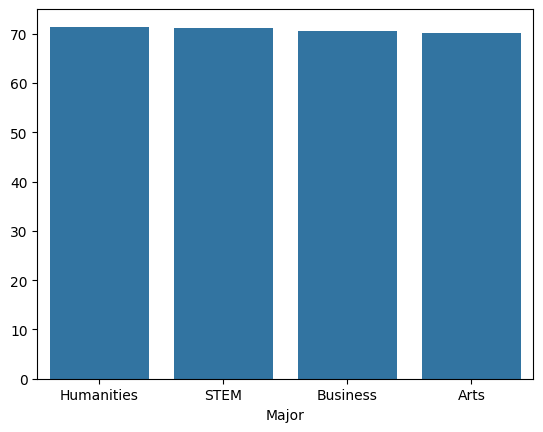

In [5]:
major = df.groupby('Major')['Average_Score'].mean().sort_values(ascending=False)
# print(major)
sns.barplot(x= major.index, y= major.values)

Do students with higher attendance rates perform better across subjects?

Text(0.5, 1.0, 'Attendance Rate vs Average Score')

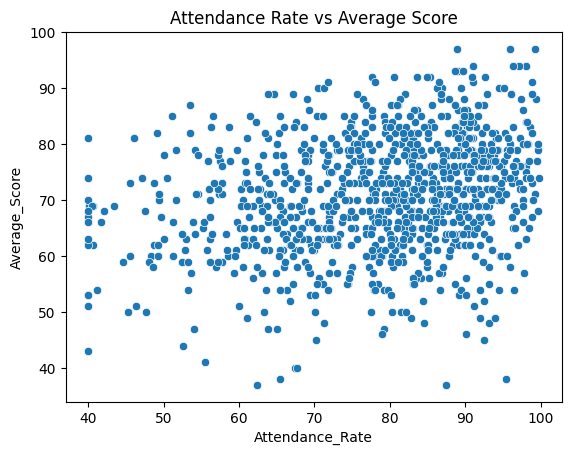

In [ ]:
sns.scatterplot(x='Attendance_Rate',y='Average_Score', data= df) 
plt.title("Attendance Rate vs Average Score")

Which subject (Math, Science, Language, History) contributes most to the overall grade?

Science_Score     0.828926
Language_Score    0.824229
History_Score     0.823114
Math_Score        0.808745
dtype: float64


<Axes: >

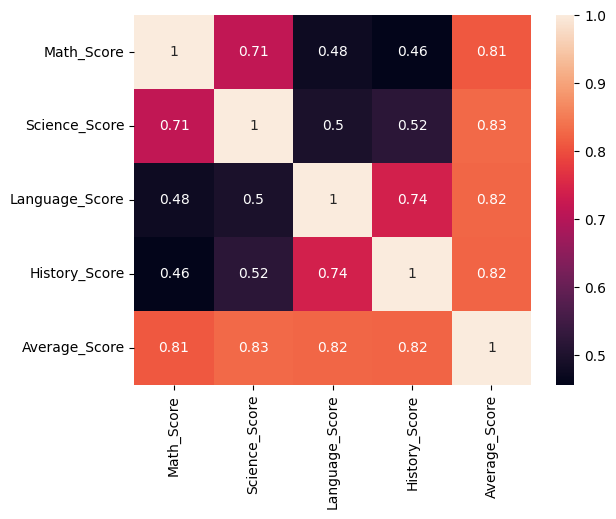

In [7]:
numcorrs = df[['Math_Score','Science_Score','Language_Score','History_Score']].corrwith(df['Average_Score'])
print(numcorrs.sort_values(ascending= False))

corr_matrix = df[['Math_Score','Science_Score','Language_Score','History_Score','Average_Score']].corr()
sns.heatmap(corr_matrix,annot= True)

Is there a relationship between sleep hours per day and stress levels?

<Axes: >

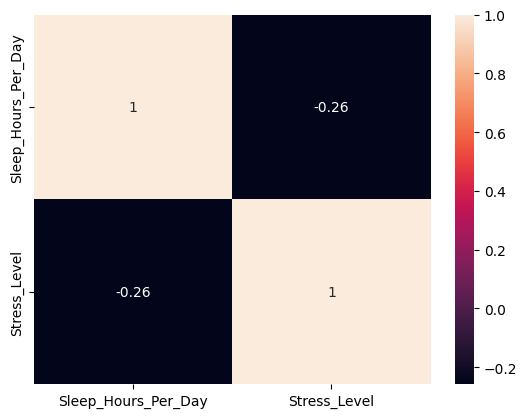

In [8]:
relation = df[['Sleep_Hours_Per_Day','Stress_Level']].corr()
# print(relation)
sns.heatmap(relation, annot=True)

Does internet access correlate with higher study hours or better scores?

<Axes: >

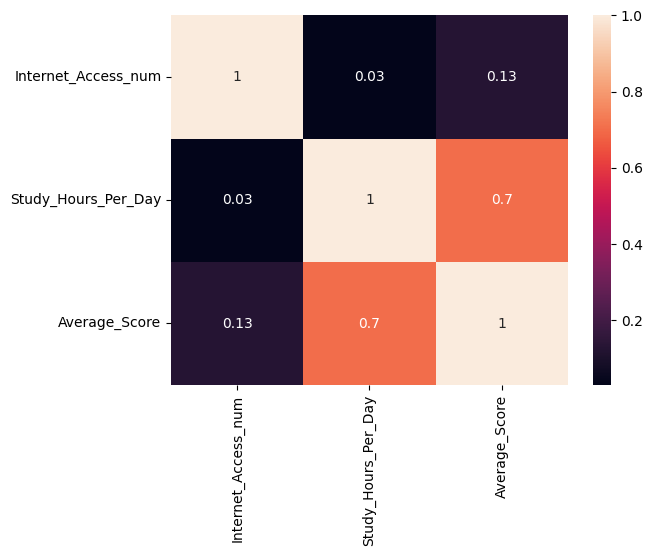

In [ ]:
grouped = df.groupby("Internet_Access")[["Study_Hours_Per_Day","Average_Score"]].mean()

df["Internet_Access_num"] = df["Internet_Access"].map({"Yes": 1 , "No": 0})
relation = df[["Internet_Access_num","Study_Hours_Per_Day","Average_Score"]].corr()
sns.heatmap(relation, annot= True)

<Axes: ylabel='Gender,Major'>

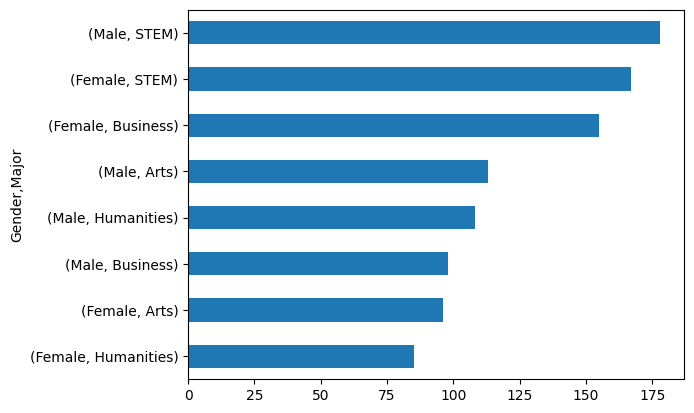

In [ ]:
df.groupby("Gender")["Major"].value_counts().sort_values().plot(kind="barh",)